# First Practice

## 1. One dimensional case

### 1.1 Plot this function within the range $x \in [−2, 2]$, for instance.

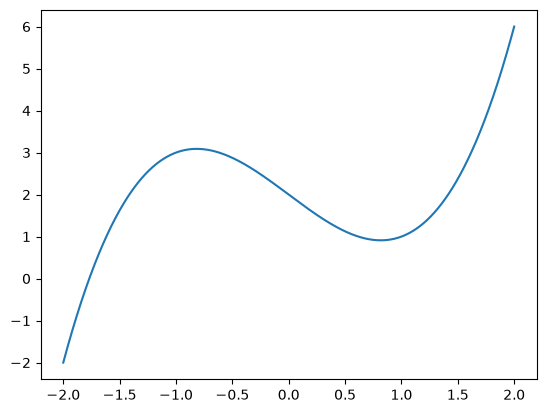

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 1000)
f_x = x**3 - 2*x + 2

plt.plot(x, f_x)



### 1.2 Compute analytically the points $x^{*}$ that satisfy $f'(x)=0$

Now we find all points $x$ where $f'(x)=0$.

We have $f'(x)=3x^{2} - 2 = 0$, by solving we find that $x_{1} = \sqrt{\frac{2}{3}}$ and $x_{2} = -\sqrt{\frac{2}{3}}$ satisfy the condition.

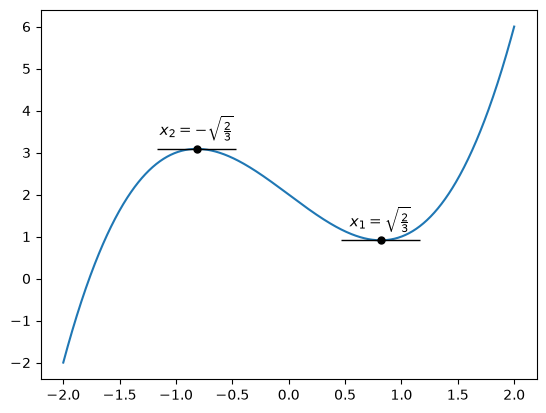

In [3]:
x = np.linspace(-2, 2, 1000)
f_x = x**3 - 2*x + 2

x_1 = np.sqrt(2/3)
x_2 = -np.sqrt(2/3)

critical_points_x = [x_1, x_2]
critical_points_y = [px**3 - 2*px + 2 for px in critical_points_x]
labels = [r'$x_1 = \sqrt{\frac{2}{3}}$', r'$x_2 = -\sqrt{\frac{2}{3}}$']

plt.plot(x, f_x)

bar_width = 0.7
line_width = 1

for cx, cy, label in zip(critical_points_x, critical_points_y, labels):
    
    plt.hlines(y=cy, xmin=cx - bar_width/2, xmax=cx + bar_width/2, color='black', linewidth=line_width)
    
    plt.plot(cx, cy, 'ko', markersize=5)
    
    offset = 0.35
    plt.annotate(
        label, 
        (cx, cy), 
        textcoords="offset points", 
        xytext=(0, 10 ), 
        ha='center',
        fontsize=11
    )

plt.show()

### 1.3

### 1.3. Second-order Taylor Expansion and Minimum/Maximum Conditions

To determine whether the critical points $x^*$ found in the previous section ($x_1 = \sqrt{\frac{2}{3}}$ and $x_2 = -\sqrt{\frac{2}{3}}$) are local minima or local maxima, we use the **2nd order Taylor expansion** of $f(x)$ around $x^*$:

$$f(x^* + d) \approx f(x^*) + d \cdot f'(x^*) + \frac{1}{2} d^2 f''(x^*)$$

where $d \in \mathbb{R}$ represents a small perturbation around $x^*$. 

Since $x^*$ is a critical point, $f'(x^*) = 0$, which simplifies the approximation to:

$$f(x^* + d) \approx f(x^*) + \frac{1}{2} d^2 f''(x^*)$$

#### Analysis of the Second Derivative:
1. **$f''(x^*) > 0$ (Convex / Local Minimum):**
   - For any perturbation $d \neq 0$, $d^2 > 0$. Therefore, $\frac{1}{2} d^2 f''(x^*) > 0$, implying $f(x^* + d) > f(x^*)$.
   - The function curves upwards, and $x^*$ is a **local minimum**.
   
2. **$f''(x^*) < 0$ (Concave / Local Maximum):**
   - $\frac{1}{2} d^2 f''(x^*) < 0$, implying $f(x^* + d) < f(x^*)$.
   - The function curves downwards, and $x^*$ is a **local maximum**.

---

#### Analytical Evaluation of $f''(x)$:
Given $f(x) = x^3 - 2x + 2$, its first derivative is $f'(x) = 3x^2 - 2$.  
Taking the derivative again gives:

$$f''(x) = 6x$$

Evaluating at our critical points:
* **At $x_1 = \sqrt{\frac{2}{3}} \approx 0.8165$:**
  $$f''\left(\sqrt{\frac{2}{3}}\right) = 6\sqrt{\frac{2}{3}} \approx 4.899 > 0$$
  Since $f''\left(x_1\right) > 0$, **$x_1 = \sqrt{\frac{2}{3}}$ is a local minimum**.

* **At $x_2 = -\sqrt{\frac{2}{3}} \approx -0.8165$:**
  $$f''\left(-\sqrt{\frac{2}{3}}\right) = -6\sqrt{\frac{2}{3}} \approx -4.899 < 0$$
  Since $f''\left(x_2\right) < 0$, **$x_2 = -\sqrt{\frac{2}{3}}$ is a local maximum**.

--- Análisis numérico de la segunda derivada ---
At x1 =  sqrt(2/3) ≈ 0.8165: f''(x1) = 4.8990 > 0  --> LOCAL MINIMUM
At x2 = -sqrt(2/3) ≈ -0.8165: f''(x2) = -4.8990 < 0  --> LOCAL MAXIMUM



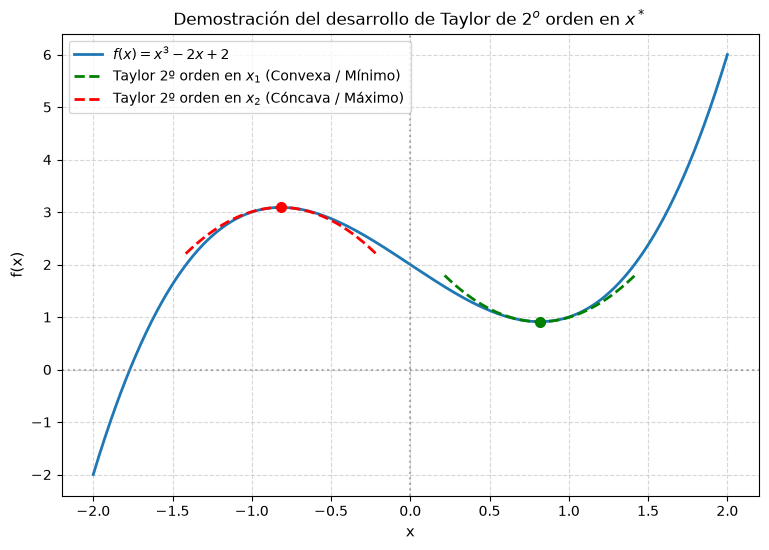

In [5]:
# 1. Función f(x) y sus derivadas f'(x) y f''(x)
def f(x):
    return x**3 - 2*x + 2

def df(x):
    return 3*x**2 - 2

def d2f(x):
    return 6*x

# 2. Puntos críticos
x1 = np.sqrt(2/3)   # Candidato a mínimo
x2 = -np.sqrt(2/3)  # Candidato a máximo

# 3. Evaluación analítica e impresión de resultados
print(f"--- Análisis numérico de la segunda derivada ---")
print(f"At x1 =  sqrt(2/3) ≈ {x1:.4f}: f''(x1) = {d2f(x1):.4f} > 0  --> LOCAL MINIMUM")
print(f"At x2 = -sqrt(2/3) ≈ {x2:.4f}: f''(x2) = {d2f(x2):.4f} < 0  --> LOCAL MAXIMUM\n")

# 4. Visualización de la aproximación de Taylor de 2º orden alrededor de los puntos críticos
x = np.linspace(-2, 2, 1000)
d = np.linspace(-0.6, 0.6, 200) # Rango de perturbación d

# Aproximaciones parabólicas de Taylor
taylor_x1 = f(x1) + 0.5 * (d**2) * d2f(x1)  # Alrededor del mínimo
taylor_x2 = f(x2) + 0.5 * (d**2) * d2f(x2)  # Alrededor del máximo

# Gráfico
plt.figure(figsize=(9, 6))
plt.plot(x, f(x), label=r'$f(x) = x^3 - 2x + 2$', color='tab:blue', linewidth=2)

# Dibujar la aproximación de Taylor en el mínimo x1
plt.plot(x1 + d, taylor_x1, '--', color='green', linewidth=2, 
         label=r'Taylor 2º orden en $x_1$ (Convexa / Mínimo)')

# Dibujar la aproximación de Taylor en el máximo x2
plt.plot(x2 + d, taylor_x2, '--', color='red', linewidth=2, 
         label=r'Taylor 2º orden en $x_2$ (Cóncava / Máximo)')

# Destacar los puntos críticos
plt.plot(x1, f(x1), 'go', markersize=7)
plt.plot(x2, f(x2), 'ro', markersize=7)

# Detalles de la figura
plt.title(r'Demostración del desarrollo de Taylor de $2^o$ orden en $x^*$', fontsize=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('f(x)', fontsize=11)
plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(0, color='gray', linestyle=':', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

### 2.2 A two dimensional function with multiple minima

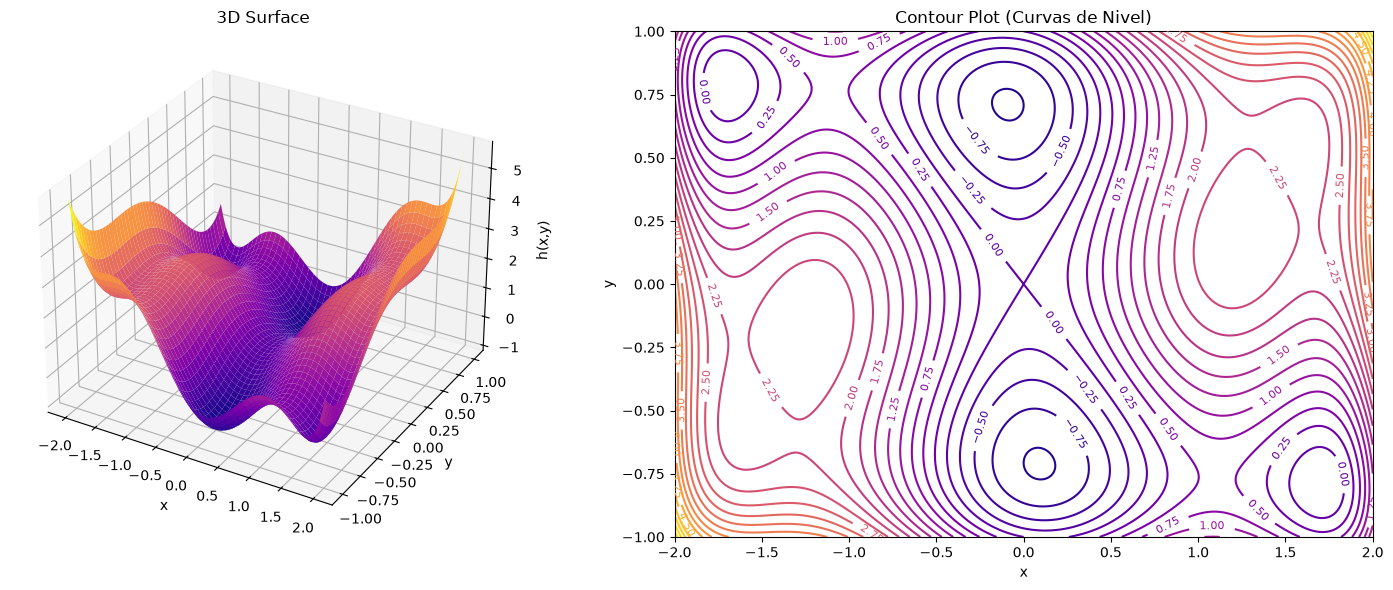

In [ ]:
x = np.linspace(-2, 2, 1000)
y = np.linspace(-1, 1, 1000)
X, Y = np.meshgrid(x,y)

h = X**2 * (4-2.1*X**2 + 1/3 * X**4) + X*Y + Y**2 * (-4+4*Y**2)


fig = plt.figure(figsize=(15, 6))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, h, cmap='plasma')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('h(x,y)')
ax1.set_title('3D Surface')

# Curvas de nivel (2D)
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, h, levels=30, cmap='plasma')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot (Curvas de Nivel)')

plt.tight_layout()
plt.show()


In [ ]:
## Calculamos el gradiente de la función h(x,y)

def grad_f(x,y):
    df_dx = 8*x - 8.4*x**3 + (4/3)*x**5 + y
    df_dy = x + 8*y - 16*y**3
    return np.array([df_dx, df_dy])

def norm_grad_f(x,y):
    grad = grad_f(x,y)
    return grad[0]**2 + grad[1]**2

In [ ]:
grad_f(0,0)

array([0., 0.])